In [9]:
import numpy as np
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt

from qdots_qll.models.single_dot_weak_coupling_GAME import SingleDotWeakCouplingGAME, true_parameters
from qdots_qll.models.game_mlp import lkl_wrapped, MLPSingleDotGAME
from equinox import filter_jit

In [2]:
m_og = SingleDotWeakCouplingGAME()
mlp = MLPSingleDotGAME()

In [3]:
times = jnp.linspace(0, 48.3, 1000)

In [4]:
f_mlp = jax.vmap(lambda t: jnp.linalg.det(mlp.fim(true_parameters,t, jnp.ones(4)/4, jnp.ones(3)/3)))(times)

In [5]:
f_og = jax.vmap(fun=lambda t: jnp.linalg.det(m_og.fim(true_parameters,t, jnp.ones(4)/4, jnp.ones(3)/3)))(times)

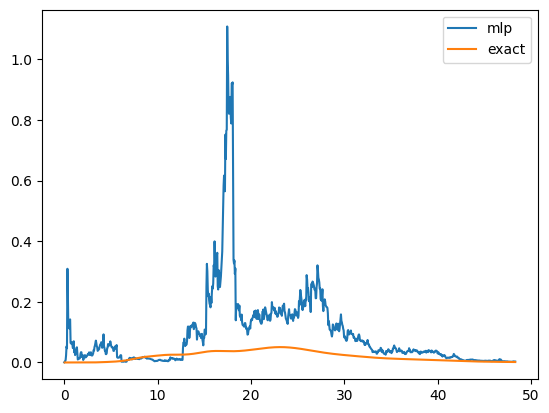

In [6]:
plt.plot(times, f_mlp[:, ],label= 'mlp')
plt.plot(times, f_og[:, ],label= 'exact')
plt.legend()
plt.show()

In [7]:
for i in range(4):
    # plt.plot(times, f_mlp[:, i, i])
    # plt.plot(times, f_og[:, i, i])
    plt.show()


In [8]:
a = lkl_wrapped(true_parameters, t=13.2)

In [9]:
pars = jnp.ones([10000, 4])*true_parameters*1.0002

In [ ]:
m_og.likelihood_particle()

In [17]:
f1 =filter_jit(jax.vmap(lambda pars: m_og.likelihood_particle(pars, t=jnp.array([13.2]))))
f2 = filter_jit(jax.vmap(lambda pars: mlp.likelihood_particle(pars, t=(13.2))))



In [20]:
f2(pars)

Array([[[[0.50185716, 0.49814284],
         [0.7410489 , 0.25895113],
         [0.6354922 , 0.3645078 ]],

        [[0.46320218, 0.5367978 ],
         [0.2609721 , 0.73902786],
         [0.36836207, 0.63163793]],

        [[0.6703263 , 0.3296737 ],
         [0.50339806, 0.49660194],
         [0.502364  , 0.49763602]],

        [[0.479001  , 0.520999  ],
         [0.67903465, 0.32096535],
         [0.26032078, 0.7396792 ]]],


       [[[0.50185716, 0.49814284],
         [0.7410489 , 0.25895113],
         [0.6354922 , 0.3645078 ]],

        [[0.46320218, 0.5367978 ],
         [0.2609721 , 0.73902786],
         [0.36836207, 0.63163793]],

        [[0.6703263 , 0.3296737 ],
         [0.50339806, 0.49660194],
         [0.502364  , 0.49763602]],

        [[0.479001  , 0.520999  ],
         [0.67903465, 0.32096535],
         [0.26032078, 0.7396792 ]]],


       [[[0.50185716, 0.49814284],
         [0.7410489 , 0.25895113],
         [0.6354922 , 0.3645078 ]],

        [[0.46320218, 0.5367978 ]

In [27]:
%timeit  -n 10  f1(pars)

25.9 ms ± 4.84 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [28]:
%timeit   -n 10 f2(pars)

The slowest run took 270.43 times longer than the fastest. This could mean that an intermediate result is being cached.
20.3 ms ± 17.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
def f_og():
    times = jnp.linspace(0, 25, 8)
    pars = jnp.ones([10000, 4])*true_parameters
    for i in range(len(times)):
        pars = pars*i/1000

        re = filter_jit(jax.vmap(lambda pars: m_og.likelihood_particle(pars, times[i])))(pars)


def f_mlp():
    times = jnp.linspace(0, 25, 8)
    pars = jnp.ones([10000, 4])*true_parameters
    for i in range(len(times)):
        pars = pars*i/1000

        re = filter_jit(jax.vmap(lambda pars: mlp.likelihood_particle(pars, times[i])))(pars)

In [10]:
%timeit  -n 5  f_og()

3.77 s ± 133 ms per loop (mean ± std. dev. of 7 runs, 5 loops each)


In [11]:
%timeit  -n 5  f_mlp()

1.47 s ± 130 ms per loop (mean ± std. dev. of 7 runs, 5 loops each)


In [12]:
f_og()

In [13]:
f_mlp()

In [80]:
%timeit f2(pars)


36.6 ms ± 1.69 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
